# Tutorial 07 — Silane: $\Gamma$-only molecular Wannierisation

The waw-native reimagining of Wannier90 tutorial 7. **SiH$_4$** sits alone in a large vacuum box, so it needs only the **$\Gamma$ point** — QE's real-wavefunction `K_POINTS {gamma}` trick, which runs roughly 2x faster and halves the memory of an explicit $k=(0,0,0)$ calculation. The 4 occupied valence bands give 4 equivalent Si–H bond MLWFs.

**Two $\Gamma$-only wrinkles.** (1) `pw2wannier90` does not implement SCDM for gamma-only wavefunctions ("Gamma_only and SCDM not implemented"), so this tutorial uses **analytic Si:$sp^3$ trial projections** instead (`write_nnkp`'s `projections=`, angular momentum code $l=-3$). (2) QE's real-wavefunction storage only keeps *half* the reciprocal sphere, so the full $\pm b$ neighbour shell `generate_nnkp` would normally pick makes `pw2wannier90` abort ("g_kpb vector is not in the list of Gs"); real `wannier90.x -pp` sidesteps this with a **half-shell** of 3 b-vectors $(1,0,0),(0,1,0),(0,0,1)$ (confirmed against the committed tutorial14 Na-chain `.mmn`, itself $\Gamma$-only), and waw's own weight solver and Z-matrix already handle a half shell (auto-detected from a missing $-b$ partner) — so `qe.generate_overlaps(..., gamma_only=True)` reproduces it directly.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
SiH$_4$ (tetrahedral, Si–H = 1.48 Å) centred in a 12-bohr cubic box — the exact geometry and box size of the classic tutorial. `gamma_only=True` forces `mp_grid = (1,1,1)` and the `K_POINTS {gamma}` card for both scf and nscf.

In [2]:
from ase import Atoms

a = 12.0 * BOHR_TO_ANG                 # 12 bohr cubic box
d = 1.056551   # Si-H bond projected onto each Cartesian axis (=> |r|=1.48 A)
positions = [[0, 0, 0],
             [ d,  d,  d], [ d, -d, -d], [-d,  d, -d], [-d, -d,  d]]
atoms = Atoms('SiH4', positions=positions,
              cell=[[a, 0, 0], [0, a, 0], [0, 0, a]], pbc=True)
WORK = HERE / 'runs' / 'silane'

si_frac = atoms.get_scaled_positions()[0]
sp3 = [(tuple(si_frac), -3, mr, 1, (0., 0., 1.), (1., 0., 0.), 1.0)
       for mr in (1, 2, 3, 4)]           # Si sp3 hybrids, l=-3, mr=1..4

ov = qe.generate_overlaps(
    atoms, (1, 1, 1), WORK, 'silane',
    ecutwfc=40, scf_kpts=(1, 1, 1), nbnd=8, num_wann=4,
    exclude_bands=[5, 6, 7, 8],          # 4 occupied bonds + a Davidson buffer
    pseudopotentials={'Si': 'Si.upf', 'H': 'H.upf'}, pseudo_dir=PSEUDO_DIR,
    ncores=NCORES, gamma_only=True, projections=sp3,
    rerun_scf=False,          # reuse a completed SCF in runs/silane/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')}, '  nntot =', ov['mmn'].shape[1])

overlap shapes: {'mmn': (1, 3, 4, 4), 'amn': (1, 4, 4), 'eig': (1, 4)}   nntot = 3


### 2. Wannierise (waw, ASE-native)
4 isolated occupied bands -> 4 MLWFs, no disentanglement.

In [3]:
result = wannierize(
    atoms, (1, 1, 1), ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=4, n_restarts=3, n_iter=5000, verbose=False,
)
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
centres = result.centres_bohr * BOHR_TO_ANG
print(f'Omega_total = {omega:.4f} Ang^2   (w90 tutorial07 reference: 4.0450 Ang^2)')
for i, (c, s) in enumerate(zip(centres, spreads)):
    print(f'  WF {i+1}: centre ({c[0]:+.3f}, {c[1]:+.3f}, {c[2]:+.3f}) A   spread {s:.4f} A^2')

Omega_total = 3.9737 Ang^2   (w90 tutorial07 reference: 4.0450 Ang^2)
  WF 1: centre (+0.769, +0.770, +0.770) A   spread 0.9937 A^2
  WF 2: centre (-0.769, +0.769, -0.769) A   spread 0.9933 A^2
  WF 3: centre (+0.770, -0.769, -0.770) A   spread 0.9934 A^2
  WF 4: centre (-0.769, -0.769, +0.770) A   spread 0.9933 A^2


### Wannier levels against the ab-initio levels at $\Gamma$
A molecule in a box sampled at $\Gamma$ has no band structure to
interpolate. The statement to check is that the Wannier Hamiltonian
returns the ab-initio eigenvalues of the manifold it spans.

 level    DFT (eV)   Wannier (eV)   diff (meV)
     0    -11.1830       -11.1830       -0.000
     1     -6.5685        -6.5685       -0.000
     2     -6.5685        -6.5685       -0.000
     3     -6.5685        -6.5685       -0.000

max |Wannier - DFT| over the 4 levels: 0.0000 meV


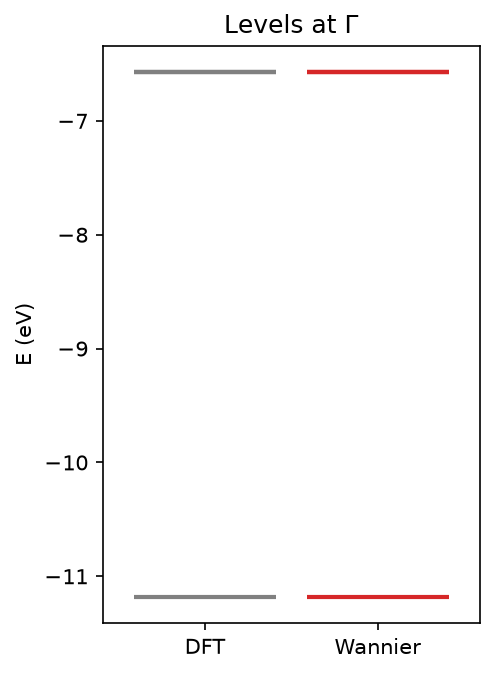

In [4]:
# --- Wannier levels vs DFT levels at Gamma --------------------------------
from waw.core.hamiltonian import interpolate_bands as _interp

_wl = np.sort(_interp(result.hr, np.zeros((1, 3)))[0]) * HARTREE_TO_EV
_dl = np.sort(ov['eig'][0])[:len(_wl)]
print(f'{"level":>6s}  {"DFT (eV)":>10s}  {"Wannier (eV)":>13s}  {"diff (meV)":>11s}')
for _i, (_d, _w) in enumerate(zip(_dl, _wl)):
    print(f'{_i:6d}  {_d:10.4f}  {_w:13.4f}  {1e3 * (_w - _d):11.3f}')
print(f'\nmax |Wannier - DFT| over the {len(_wl)} levels: '
      f'{1e3 * np.abs(_wl - _dl).max():.4f} meV')

_fig, _ax = plt.subplots(figsize=(3.4, 4.6), dpi=150)
for _i, (_d, _w) in enumerate(zip(_dl, _wl)):
    _ax.hlines(_d, 0.0, 0.9, color='0.5', lw=2.0)
    _ax.hlines(_w, 1.1, 2.0, color='C3', lw=2.0)
_ax.set_xticks([0.45, 1.55]); _ax.set_xticklabels(['DFT', 'Wannier'])
_ax.set_xlim(-0.2, 2.2); _ax.set_ylabel('E (eV)')
_ax.set_title(r'Levels at $\Gamma$')
plt.tight_layout(); plt.show()


Four **equivalent** MLWFs (same spread, related by the $T_d$ symmetry), each centred partway along a Si–H bond — bond-centred $sp^3$ orbitals, matching the classic tutorial's picture (the small offset from the reference $\Omega$ is the PseudoDojo Si pseudo vs. the historical norm-conserving one).

### 3. The localised (on-site) Hamiltonian
A single-point molecule has no $k$-dispersion, so there is no band structure to interpolate — but the Wannier gauge still gives a physically meaningful **on-site Hamiltonian** $H(R=0)$ in the localised bond basis, distinct from the delocalised canonical Kohn-Sham eigenvalues.

In [5]:
H0 = result.hr.H_R[np.all(result.hr.R_vectors == 0, axis=1)][0].detach().cpu().numpy()
H0_eV = np.real(H0) * HARTREE_TO_EV
print('H(0) diagonal (bond on-site energies, eV):', np.round(np.diag(H0_eV), 3))
print('H(0) largest off-diagonal coupling (eV):   ',
      round(float(np.abs(H0_eV - np.diag(np.diag(H0_eV))).max()), 3))
print('canonical KS eigenvalues (eV):            ', np.round(ov["eig"][0], 3))

H(0) diagonal (bond on-site energies, eV): [-7.722 -7.722 -7.722 -7.722]
H(0) largest off-diagonal coupling (eV):    1.119
canonical KS eigenvalues (eV):             [-11.183  -6.568  -6.568  -6.568]


The four bond orbitals are degenerate on-site (symmetry again) with a sizeable inter-bond coupling — the localised basis trades the canonical picture (one deep bonding level + three degenerate ones, reflecting the molecule's point group) for four equivalent, chemically intuitive $\sigma$-bond orbitals; diagonalising $H(0)$ recovers the same four canonical eigenvalues.

**Takeaway.** $\Gamma$-only Wannierisation of an isolated molecule needs two adjustments from the periodic recipe — analytic projections (SCDM does not support gamma-only in `pw2wannier90`) and a half b-vector shell (QE's real-wavefunction storage) — both already understood by waw's existing machinery, so the rest of the pipeline (`generate_overlaps` -> `wannierize`) is unchanged.